<a href="https://colab.research.google.com/github/Mystic2122/CSC665_AI_Team10/blob/Nick/model_testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [7]:
# Load models
import json
import tensorflow as tf

cnn_model_path = "/content/drive/MyDrive/pokemon_cnn.h5"
mobilenet_model_path = "/content/drive/MyDrive/pokemon_mobile_net.h5"

cnn_model = tf.keras.models.load_model(cnn_model_path)
mobilenet_model = tf.keras.models.load_model(mobilenet_model_path)

print("Models loaded successfully!")

# Load Labels
labels_path = "/content/drive/MyDrive/pokemon_labels.json"
with open(labels_path, "r") as f:
    labels = json.load(f)
print("Loaded labels")

Models loaded successfully!
Loaded labels


Saving snorlax.jpg to snorlax (2).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


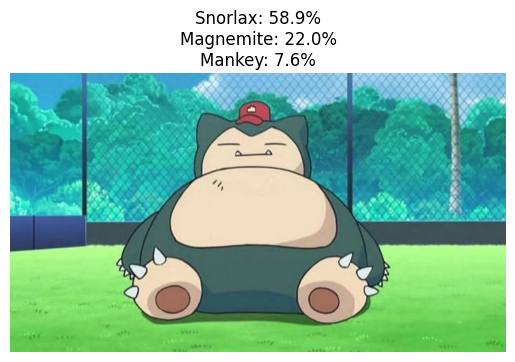

Snorlax: 58.9%
Magnemite: 22.0%
Mankey: 7.6%


In [9]:
# TOP 3 PREDICTIONS USING CNN MODEL
from google.colab import files
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

# ---- UPLOAD IMAGE ----
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# ---- PREPROCESS ----
img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, 0) / 255.0

# ---- PREDICT ----
preds = cnn_model.predict(img_array)[0]   # <--- OR cnn_model.predict(img_array)[0]

# ---- GET TOP 3 ----
top3_idx = preds.argsort()[-3:][::-1]   # last 3, descending order

top3_labels = [(labels[i], preds[i] * 100) for i in top3_idx]

# ---- DISPLAY RESULT ----
plt.imshow(plt.imread(img_path))
plt.axis("off")

title = "\n".join([f"{name}: {conf:.1f}%" for name, conf in top3_labels])
plt.title(title)
plt.show()

# Also print them cleanly
for name, conf in top3_labels:
    print(f"{name}: {conf:.1f}%")

Saving snorlax.jpg to snorlax (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


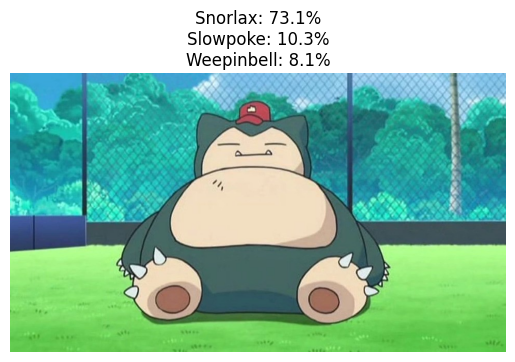

Snorlax: 73.1%
Slowpoke: 10.3%
Weepinbell: 8.1%


In [8]:
# TOP 3 PREDICTIONS USING MOBILE NET MODEL
from google.colab import files
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

# ---- UPLOAD IMAGE ----
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# ---- PREPROCESS ----
img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, 0) / 255.0

# ---- PREDICT ----
preds = mobilenet_model.predict(img_array)[0]   # <--- OR cnn_model.predict(img_array)[0]

# ---- GET TOP 3 ----
top3_idx = preds.argsort()[-3:][::-1]   # last 3, descending order

top3_labels = [(labels[i], preds[i] * 100) for i in top3_idx]

# ---- DISPLAY RESULT ----
plt.imshow(plt.imread(img_path))
plt.axis("off")

title = "\n".join([f"{name}: {conf:.1f}%" for name, conf in top3_labels])
plt.title(title)
plt.show()

# Also print them cleanly
for name, conf in top3_labels:
    print(f"{name}: {conf:.1f}%")